# Pertemuan 2: Data Preprocessing dan Exploratory Data Analysis (EDA)

**Nama:** MUH. ALI IMRAN  
**NIM:** 105841113523  
**Program Studi:** Informatika  
**Mata Kuliah:** Applied Machine Learning

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Semua library berhasil di-import!")

Semua library berhasil di-import!


In [29]:
# Load dataset Titanic
df = sns.load_dataset("titanic")

print("=== 5 BARIS PERTAMA ===")
display(df.head())

print("\n=== INFO DATASET ===")
df.info()

print("\n=== UKURAN DATASET ===")
print(f"Jumlah baris : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

print("\n=== NAMA KOLOM ===")
print(df.columns.tolist())

=== 5 BARIS PERTAMA ===


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



=== INFO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

=== UKURAN DATASET ===
Jumlah baris : 891
Jumlah kolom : 15

=== NAMA K

## 2. Pemeriksaan Missing Values

Pada tahap ini dilakukan pengecekan data yang kosong (missing values) pada setiap kolom. Data kosong perlu diketahui agar dapat ditangani sebelum proses analisis dan pemodelan.

In [30]:
# Mengecek jumlah missing values
missing = df.isnull().sum()

print("=== JUMLAH MISSING VALUES ===")
print(missing)

print("\n=== PERSENTASE MISSING VALUES ===")
print((missing / len(df) * 100).round(2))

=== JUMLAH MISSING VALUES ===
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

=== PERSENTASE MISSING VALUES ===
survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64


## 3. Visualisasi Missing Values

Heatmap digunakan untuk melihat posisi data yang kosong secara visual. Warna pada heatmap membantu mengetahui kolom mana yang memiliki banyak missing values.

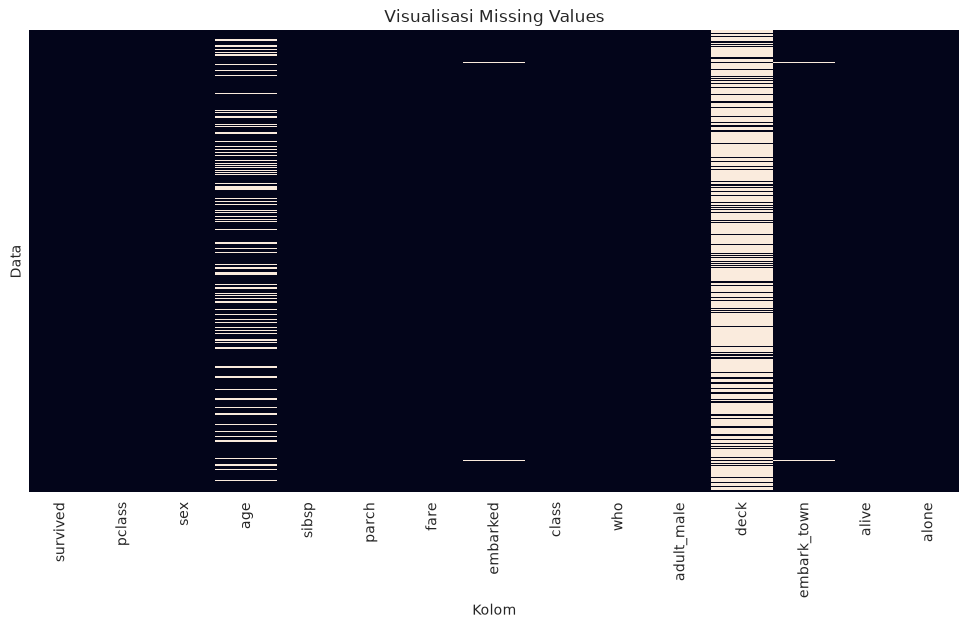

In [31]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

plt.title("Visualisasi Missing Values")
plt.xlabel("Kolom")
plt.ylabel("Data")
plt.show()

## 4. Penanganan Missing Values

Missing values ditangani dengan beberapa strategi, yaitu menghapus baris yang memiliki data kosong, mengisi data dengan nilai median atau modus, dan menggunakan SimpleImputer.

In [32]:
# Strategi 1: Menghapus baris yang memiliki missing values
df_dropped = df.dropna()

print("Data sebelum dihapus:", df.shape)
print("Data setelah dihapus:", df_dropped.shape)

Data sebelum dihapus: (891, 15)
Data setelah dihapus: (182, 15)


In [33]:
# Strategi 2: Mengisi missing values

df_filled = df.copy()

# Kolom age diisi dengan median
df_filled["age"] = df_filled["age"].fillna(df_filled["age"].median())

# Kolom embarked dan embark_town diisi dengan modus
df_filled["embarked"] = df_filled["embarked"].fillna(df_filled["embarked"].mode()[0])
df_filled["embark_town"] = df_filled["embark_town"].fillna(df_filled["embark_town"].mode()[0])

print("Missing values setelah diisi:")
print(df_filled.isnull().sum())

Missing values setelah diisi:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64


In [34]:
# Strategi 3: SimpleImputer untuk kolom numerik

df_imputed = df.copy()

numeric_cols = ["age", "fare", "sibsp", "parch"]

imputer = SimpleImputer(strategy="mean")

df_imputed[numeric_cols] = imputer.fit_transform(
    df_imputed[numeric_cols]
)

print("Missing values setelah SimpleImputer:")
print(df_imputed[numeric_cols].isnull().sum())

Missing values setelah SimpleImputer:
age      0
fare     0
sibsp    0
parch    0
dtype: int64


In [35]:
# Mengecek data duplikat
jumlah_duplikat = df.duplicated().sum()

print("Jumlah data duplikat:", jumlah_duplikat)

# Menghapus duplikat jika ada
df_clean = df.drop_duplicates()

print("Ukuran data sebelum:", df.shape)
print("Ukuran data setelah:", df_clean.shape)

Jumlah data duplikat: 107
Ukuran data sebelum: (891, 15)
Ukuran data setelah: (784, 15)


### Keputusan Data Cleaning

1. Missing values pada kolom `age` diisi menggunakan median karena median lebih tahan terhadap nilai ekstrem.
2. Missing values pada `embarked` dan `embark_town` diisi menggunakan modus karena kedua kolom tersebut berisi data kategori.
3. Data duplikat dihapus agar tidak memengaruhi hasil analisis.
4. Kolom `deck` memiliki banyak data kosong, sehingga tidak digunakan sebagai fokus utama analisis.

## Task 2: Outlier Detection and Handling

Pada tahap ini, outlier akan dideteksi menggunakan metode IQR pada tiga kolom numerik, yaitu `age`, `fare`, dan `sibsp`.

In [36]:
# Memilih 3 kolom numerik
outlier_cols = ["age", "fare", "sibsp"]

# Fungsi untuk mendeteksi outlier dengan IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower) | (data[column] > upper)
    ]
    
    return outliers, lower, upper

# Mengecek jumlah outlier
for col in outlier_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    
    print(f"{col}:")
    print(f"  Batas bawah : {lower:.2f}")
    print(f"  Batas atas  : {upper:.2f}")
    print(f"  Jumlah outlier: {len(outliers)}")
    print()

age:
  Batas bawah : -6.69
  Batas atas  : 64.81
  Jumlah outlier: 11

fare:
  Batas bawah : -26.72
  Batas atas  : 65.63
  Jumlah outlier: 116

sibsp:
  Batas bawah : -1.50
  Batas atas  : 2.50
  Jumlah outlier: 46



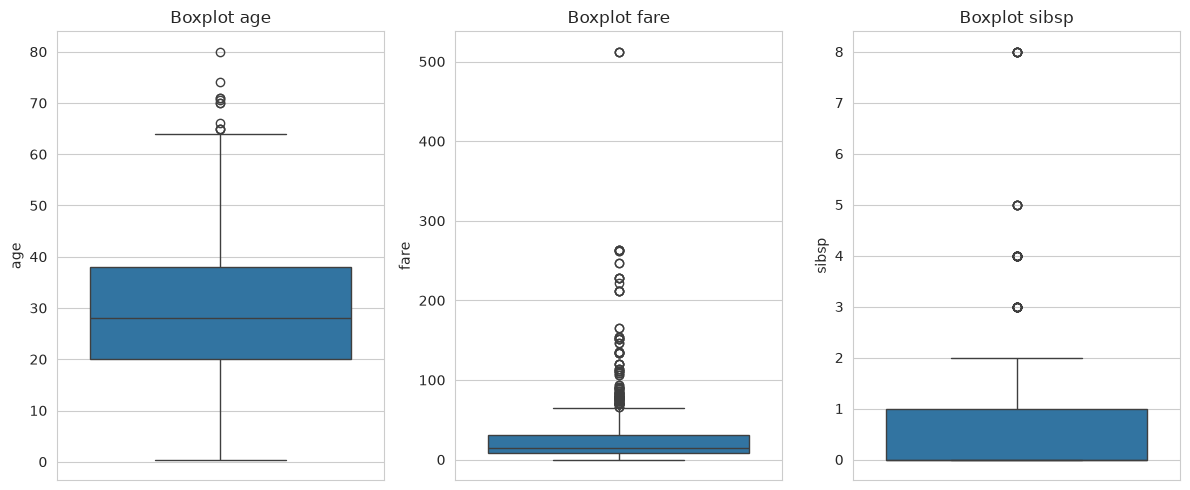

In [37]:
# Boxplot sebelum penanganan outlier

plt.figure(figsize=(12, 5))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot {col}")

plt.tight_layout()
plt.show()

In [38]:
# Metode 1: Capping/Clipping menggunakan batas IQR

df_capped = df.copy()

for col in outlier_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_capped[col] = df_capped[col].clip(lower, upper)

print("Capping berhasil dilakukan.")

Capping berhasil dilakukan.


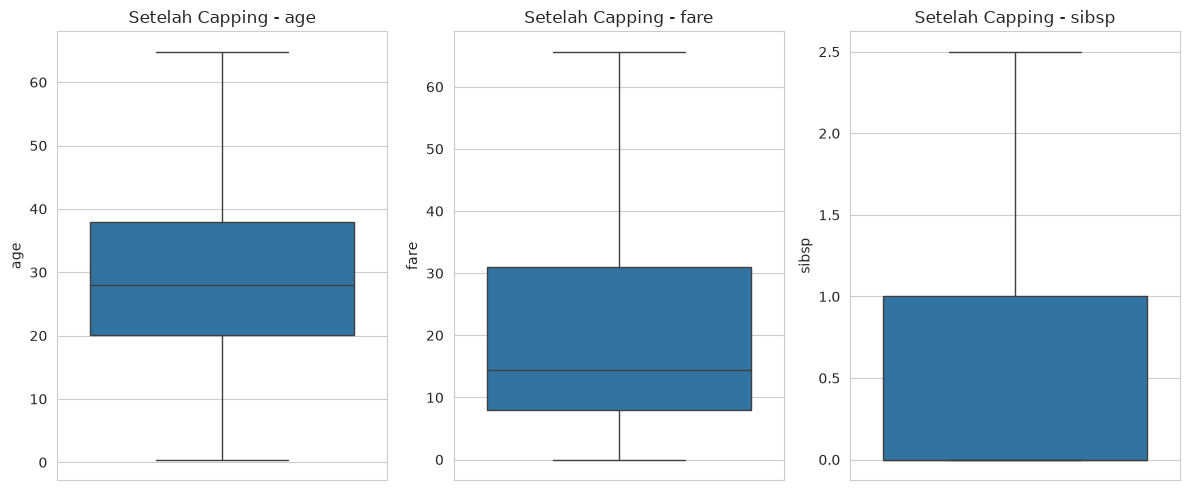

In [39]:
# Boxplot setelah capping

plt.figure(figsize=(12, 5))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_capped[col])
    plt.title(f"Setelah Capping - {col}")

plt.tight_layout()
plt.show()

In [40]:
# Metode 2: Menghapus data yang mengandung outlier

df_removed = df.copy()

for col in outlier_cols:
    Q1 = df_removed[col].quantile(0.25)
    Q3 = df_removed[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_removed = df_removed[
        (df_removed[col] >= lower) &
        (df_removed[col] <= upper)
    ]

print("Jumlah data awal :", len(df))
print("Jumlah data setelah outlier dihapus :", len(df_removed))
print("Jumlah data yang dihapus :", len(df) - len(df_removed))

Jumlah data awal : 891
Jumlah data setelah outlier dihapus : 575
Jumlah data yang dihapus : 316


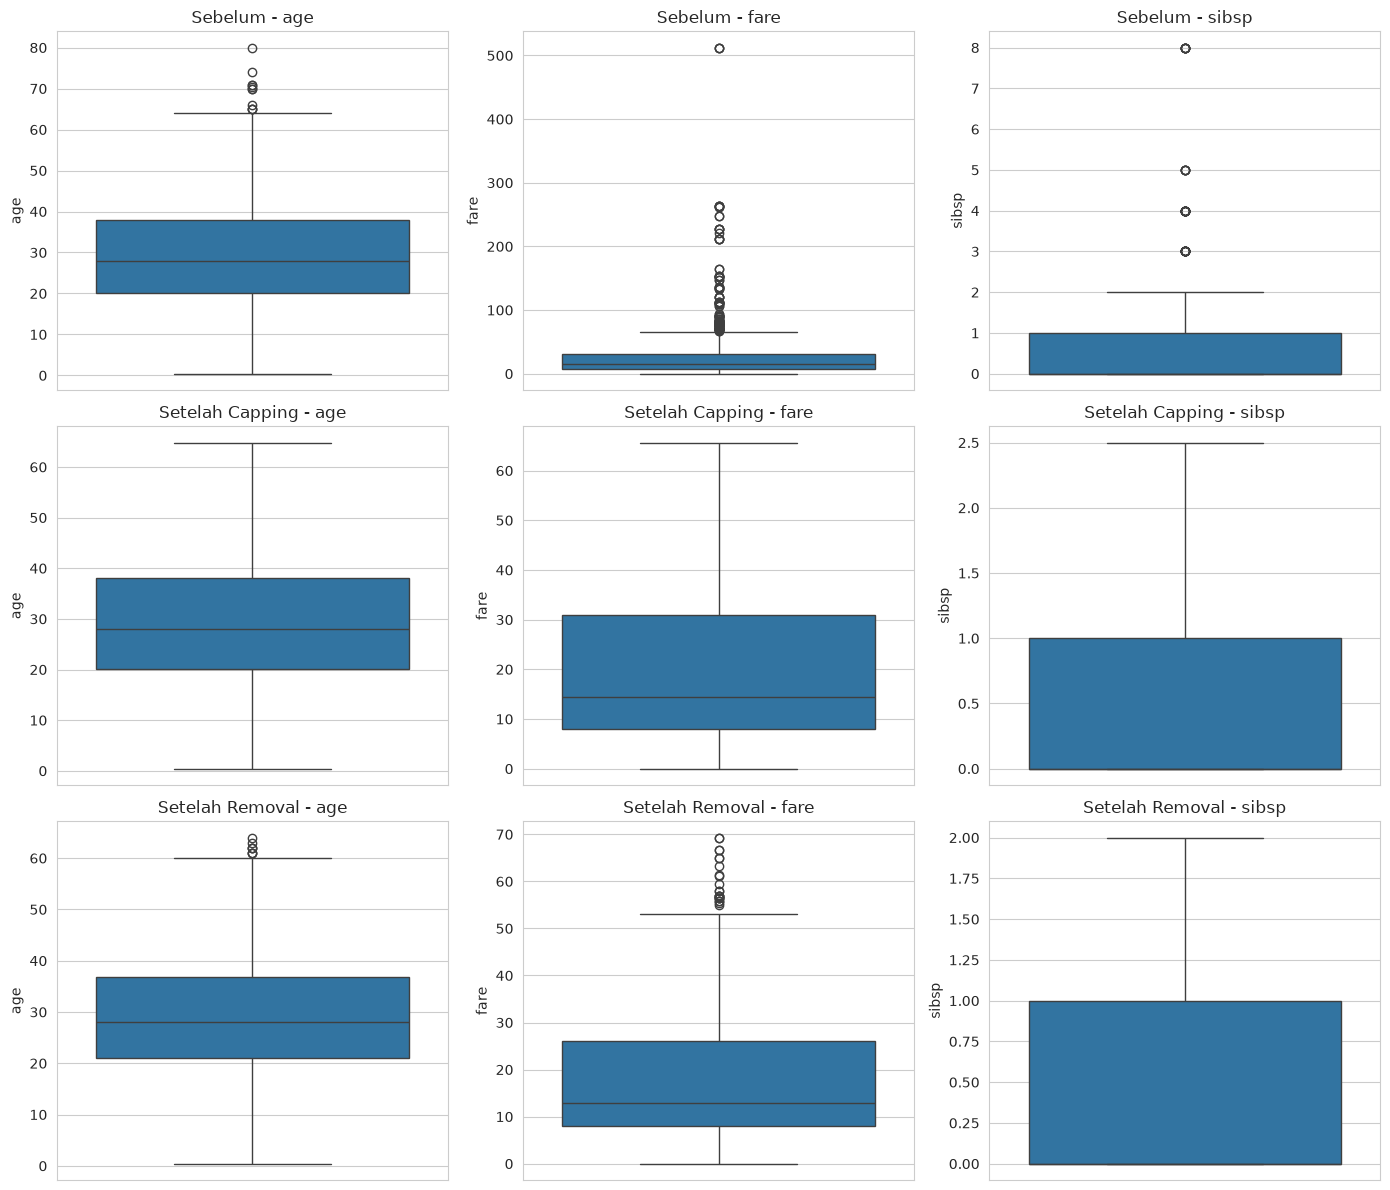

In [41]:
# Perbandingan sebelum, setelah capping, dan setelah removal

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[0, i])
    axes[0, i].set_title(f"Sebelum - {col}")

    sns.boxplot(y=df_capped[col], ax=axes[1, i])
    axes[1, i].set_title(f"Setelah Capping - {col}")

    sns.boxplot(y=df_removed[col], ax=axes[2, i])
    axes[2, i].set_title(f"Setelah Removal - {col}")

plt.tight_layout()
plt.show()

### Kesimpulan Task 2

Outlier ditemukan pada kolom `age`, `fare`, dan `sibsp` menggunakan metode IQR. Penanganan dengan capping mempertahankan jumlah data, sedangkan removal menghapus data yang dianggap outlier. Capping lebih aman jika ingin mempertahankan jumlah data, sedangkan removal dapat digunakan jika outlier dianggap mengganggu analisis.

## Task 3: Normalisasi dan Standardisasi

Pada tahap ini dilakukan normalisasi Min-Max dan standardisasi menggunakan StandardScaler pada lima kolom numerik.

In [42]:
# Memilih 5 kolom numerik
numeric_cols = ["age", "fare", "sibsp", "parch", "pclass"]

df_numeric = df[numeric_cols].copy()

print("Kolom yang digunakan:")
print(numeric_cols)

print("\nJumlah data:")
print(df_numeric.shape)

Kolom yang digunakan:
['age', 'fare', 'sibsp', 'parch', 'pclass']

Jumlah data:
(891, 5)


In [43]:
# Min-Max Normalization
minmax_scaler = MinMaxScaler()

df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_numeric),
    columns=numeric_cols
)

print("Hasil Min-Max Normalization:")
display(df_minmax.head())

Hasil Min-Max Normalization:


,age,fare,sibsp,parch,pclass
0,0.271174,0.014151,0.125,0.0,1.0
1,0.472229,0.139136,0.125,0.0,0.0
2,0.321438,0.015469,0.000,0.0,1.0
3,0.434531,0.103644,0.125,0.0,0.0
4,0.434531,0.015713,0.000,0.0,1.0


In [44]:
# Standardization menggunakan StandardScaler
standard_scaler = StandardScaler()

df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df_numeric),
    columns=numeric_cols
)

print("Hasil Standardization:")
display(df_standard.head())

Hasil Standardization:


,age,fare,sibsp,parch,pclass
0,-0.530377,-0.502445,0.432793,-0.473674,0.827377
1,0.571831,0.786845,0.432793,-0.473674,-1.566107
2,-0.254825,-0.488854,-0.474545,-0.473674,0.827377
3,0.365167,0.420730,0.432793,-0.473674,-1.566107
4,0.365167,-0.486337,-0.474545,-0.473674,0.827377


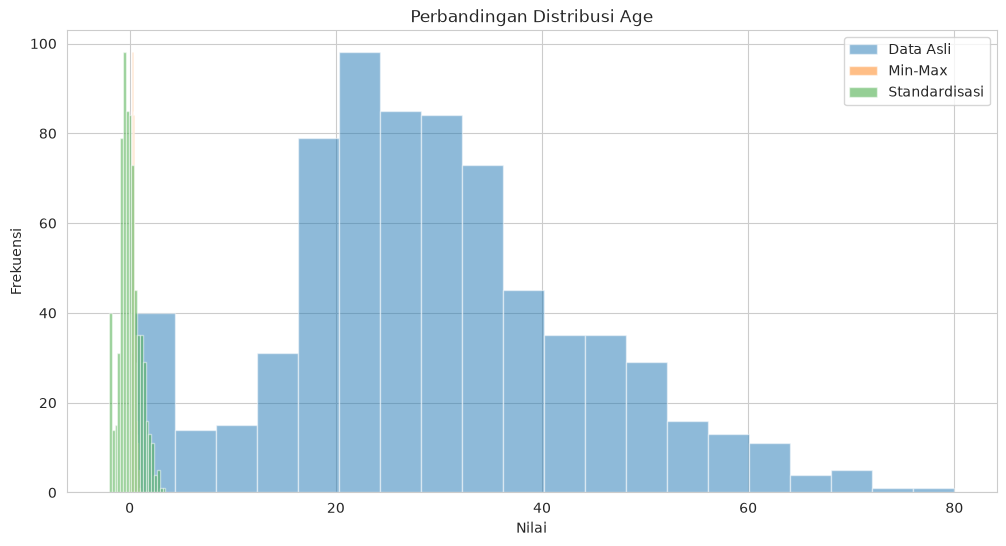

In [45]:
# Visualisasi perbandingan

plt.figure(figsize=(12, 6))

plt.hist(df_numeric["age"].dropna(), bins=20, alpha=0.5, label="Data Asli")
plt.hist(df_minmax["age"], bins=20, alpha=0.5, label="Min-Max")
plt.hist(df_standard["age"], bins=20, alpha=0.5, label="Standardisasi")

plt.title("Perbandingan Distribusi Age")
plt.xlabel("Nilai")
plt.ylabel("Frekuensi")
plt.legend()
plt.show()

### Perbedaan Normalisasi dan Standardisasi

**Normalisasi (Min-Max)** digunakan untuk mengubah nilai ke rentang tertentu, biasanya 0 sampai 1. Metode ini cocok ketika data memiliki skala yang berbeda dan algoritma membutuhkan rentang nilai yang sama.

**Standardisasi** mengubah data agar memiliki rata-rata mendekati 0 dan standar deviasi 1. Metode ini cocok untuk algoritma yang bekerja berdasarkan jarak atau distribusi data, seperti Logistic Regression, SVM, dan K-Means.

## Task 4: Exploratory Data Analysis (EDA)

EDA dilakukan untuk melihat pola, distribusi, dan hubungan antarvariabel pada dataset Titanic.

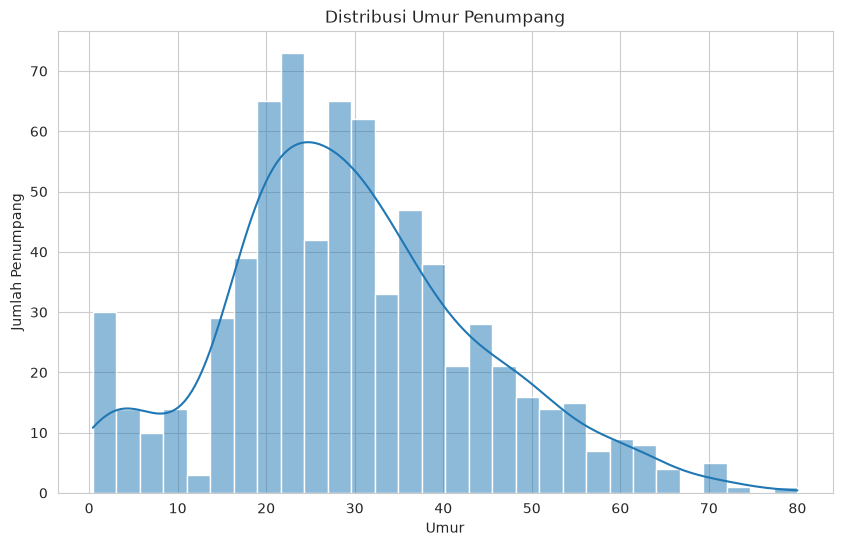

In [46]:
# Distribusi umur penumpang

plt.figure(figsize=(10, 6))

sns.histplot(df["age"].dropna(), bins=30, kde=True)

plt.title("Distribusi Umur Penumpang")
plt.xlabel("Umur")
plt.ylabel("Jumlah Penumpang")
plt.show()

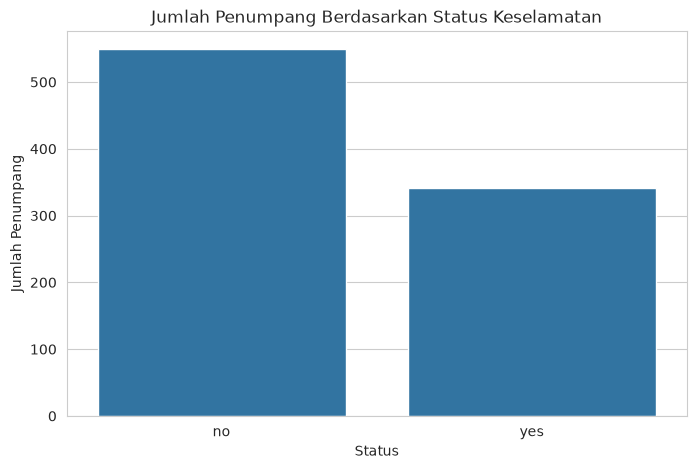

In [47]:
# Jumlah penumpang berdasarkan status keselamatan

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="alive")

plt.title("Jumlah Penumpang Berdasarkan Status Keselamatan")
plt.xlabel("Status")
plt.ylabel("Jumlah Penumpang")
plt.show()

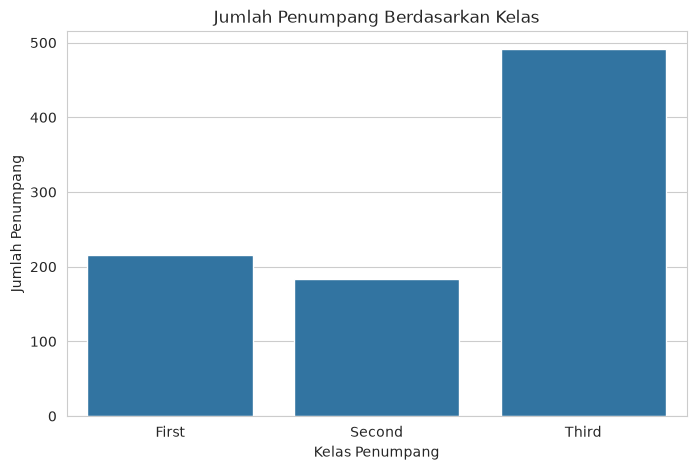

In [48]:
# Jumlah penumpang berdasarkan kelas

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="class")

plt.title("Jumlah Penumpang Berdasarkan Kelas")
plt.xlabel("Kelas Penumpang")
plt.ylabel("Jumlah Penumpang")
plt.show()

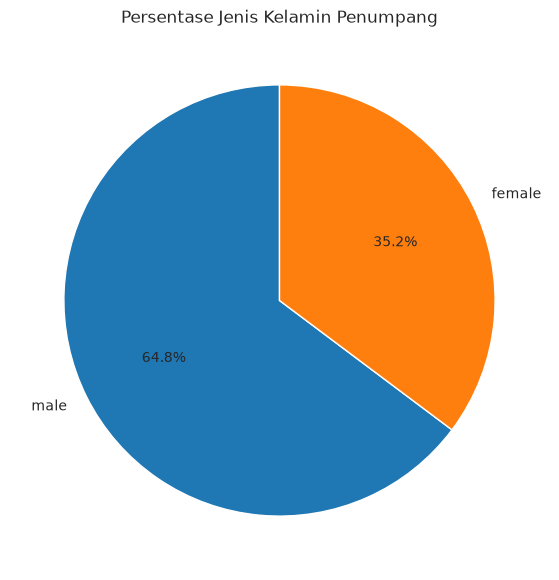

In [49]:
# Perbandingan jenis kelamin penumpang

plt.figure(figsize=(7, 7))

df["sex"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Persentase Jenis Kelamin Penumpang")
plt.ylabel("")
plt.show()

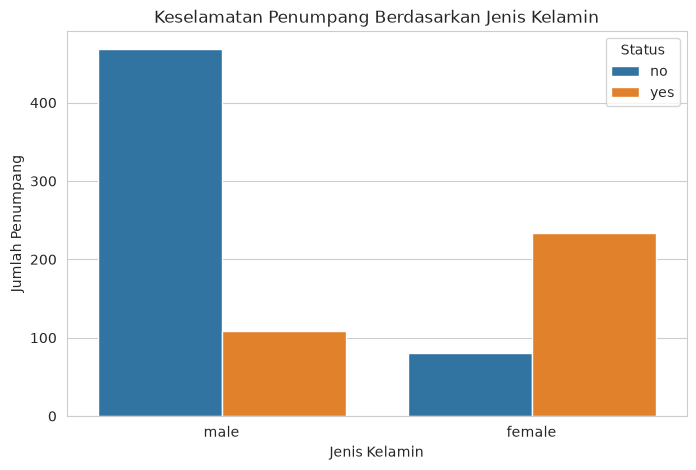

In [50]:
# Hubungan jenis kelamin dengan keselamatan

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="sex", hue="alive")

plt.title("Keselamatan Penumpang Berdasarkan Jenis Kelamin")
plt.xlabel("Jenis Kelamin")
plt.ylabel("Jumlah Penumpang")
plt.legend(title="Status")

plt.show()

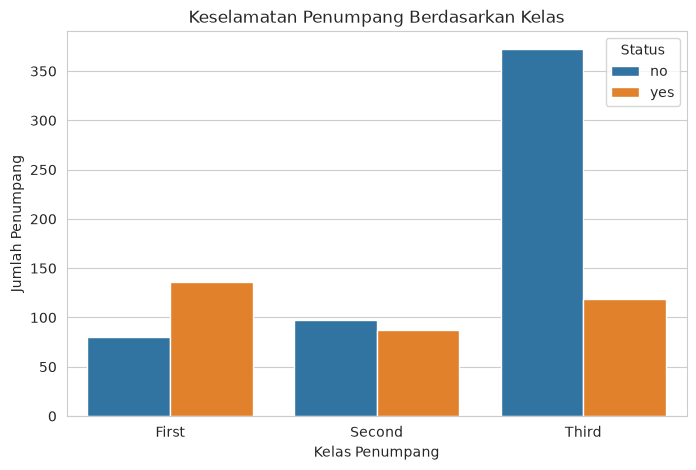

In [51]:
# Hubungan kelas penumpang dengan keselamatan

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="class", hue="alive")

plt.title("Keselamatan Penumpang Berdasarkan Kelas")
plt.xlabel("Kelas Penumpang")
plt.ylabel("Jumlah Penumpang")
plt.legend(title="Status")

plt.show()

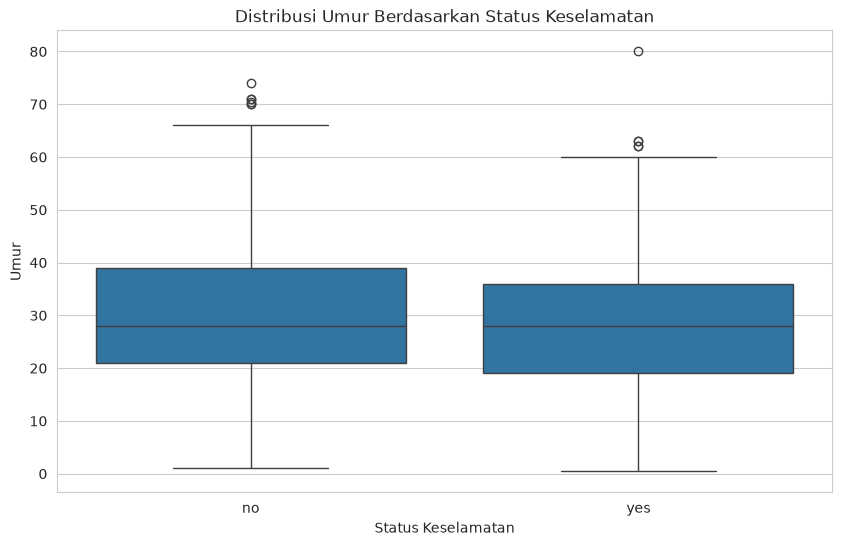

In [52]:
# Distribusi umur berdasarkan status keselamatan

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="alive", y="age")

plt.title("Distribusi Umur Berdasarkan Status Keselamatan")
plt.xlabel("Status Keselamatan")
plt.ylabel("Umur")

plt.show()

=== CORRELATION MATRIX ===


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


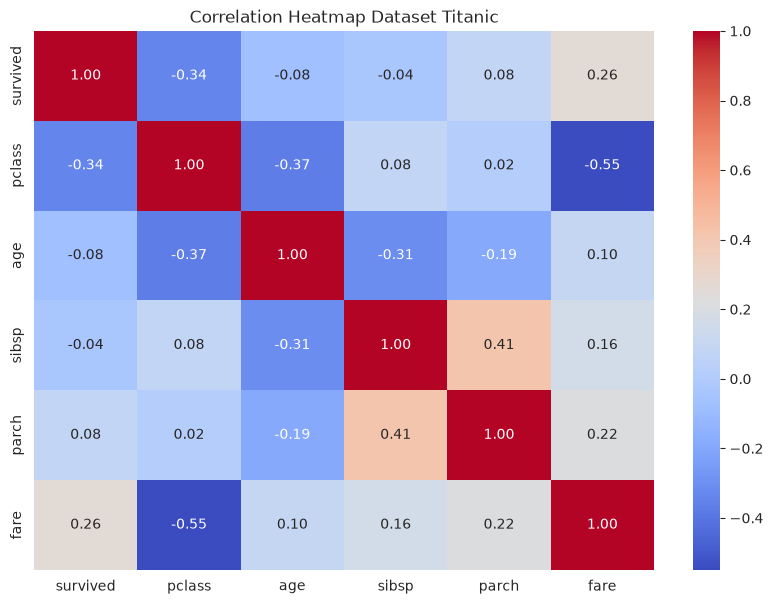

In [53]:
# Membuat correlation matrix

corr = df.select_dtypes(include="number").corr()

print("=== CORRELATION MATRIX ===")
display(corr)

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap Dataset Titanic")
plt.show()

### 5 Insight dari EDA

1. Jumlah penumpang yang tidak selamat lebih banyak dibandingkan penumpang yang selamat.
2. Penumpang perempuan memiliki peluang selamat lebih tinggi dibandingkan laki-laki.
3. Penumpang kelas pertama memiliki peluang selamat lebih tinggi dibandingkan kelas kedua dan ketiga.
4. Penumpang kelas ketiga merupakan kelompok penumpang yang cukup banyak dalam dataset.
5. Variabel `pclass` memiliki hubungan dengan `survived`, sehingga kelas penumpang dapat menjadi fitur yang penting untuk pemodelan.

### Rekomendasi Fitur untuk Pemodelan

Berdasarkan hasil EDA, fitur yang penting untuk pemodelan adalah `pclass`, `sex`, `age`, `fare`, dan `sibsp`. Fitur-fitur tersebut dapat digunakan untuk membantu memprediksi kemungkinan keselamatan penumpang.